# 🚀 TP 5 : attention et auto-encodeur de débruitage

**Durée indicative : 2 h 30 — Ce TP isole deux mécanismes ; il n'entraîne pas un LLM.**

## Objectifs observables

1. calculer l'attention par produit scalaire mis à l'échelle ;
2. vérifier que chaque ligne de poids somme à 1 ;
3. distinguer poids aléatoires et attention apprise ;
4. évaluer un auto-encodeur sur des images synthétiques non vues ;
5. appliquer un masque causal simple.


## 1. Imports et Configuration


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
print(f"PyTorch version : {torch.__version__}")


PyTorch version : 2.14.0


## 2. Self-attention pas à pas

$$\operatorname{Attention}(Q,K,V)=\operatorname{softmax}
\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

1. `Q @ K.T` calcule des compatibilités entre requêtes et clés.
2. La division par $\sqrt{d_k}$ limite la saturation du softmax lorsque la dimension augmente.
3. `softmax` normalise chaque ligne en poids positifs de somme 1.
4. La multiplication par `V` construit une somme pondérée des valeurs.

**Attention à l'interprétation** : les projections ci-dessous sont initialisées aléatoirement et ne sont pas entraînées. La matrice illustre le calcul, pas une relation linguistique apprise.


In [2]:
seq_len = 4
d_k = 8

# Simulation de représentations de 4 tokens (ex: "Le", "chat", "dort", "paisiblement")
X = torch.randn(seq_len, d_k)

# Matrices de projection linéaire apprises pour Requête, Clé et Valeur
W_q = nn.Linear(d_k, d_k, bias=False)
W_k = nn.Linear(d_k, d_k, bias=False)
W_v = nn.Linear(d_k, d_k, bias=False)

Q = W_q(X)
K = W_k(X)
V = W_v(X)

# 1. Produit scalaire Q * K^T pour mesurer la similarité de chaque mot avec tous les autres
scores = torch.matmul(Q, K.transpose(-2, -1))

# 2. Mise à l'échelle par racine carrée de d_k pour éviter la saturation du softmax
scaled_scores = scores / np.sqrt(d_k)

# 3. Softmax pour obtenir une distribution de probabilités (somme des lignes = 1)
attention_weights = F.softmax(scaled_scores, dim=-1)

# 4. Somme pondérée des valeurs V
context_representations = torch.matmul(attention_weights, V)

print("Matrice des poids d'attention (Affinités mutuelles entre les 4 mots) :")
print(attention_weights.detach().numpy().round(3))


Matrice des poids d'attention (Affinités mutuelles entre les 4 mots) :
[[0.333 0.217 0.185 0.265]
 [0.196 0.257 0.231 0.316]
 [0.356 0.255 0.257 0.132]
 [0.172 0.268 0.367 0.193]]


Visualisons la matrice des poids d'attention sous forme de carte thermique (*Heatmap*) :


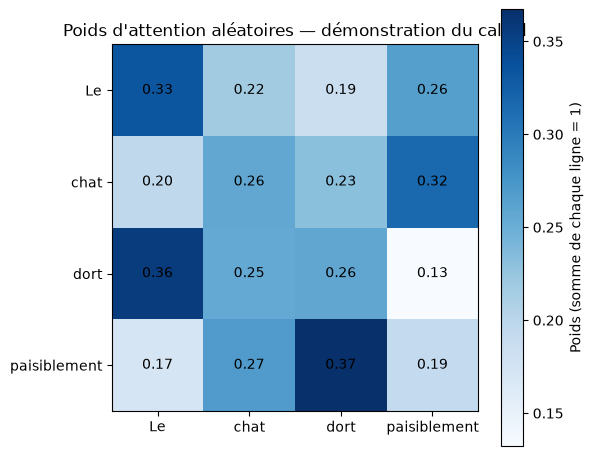

In [3]:
tokens = ["Le", "chat", "dort", "paisiblement"]
weights_np = attention_weights.detach().numpy()

plt.figure(figsize=(6, 5))
plt.imshow(weights_np, cmap='Blues')
plt.xticks(range(seq_len), tokens)
plt.yticks(range(seq_len), tokens)
plt.title("Poids d'attention aléatoires — démonstration du calcul")
plt.colorbar(label="Poids (somme de chaque ligne = 1)")

for row in range(seq_len):
    for column in range(seq_len):
        plt.text(
            column,
            row,
            f"{weights_np[row, column]:.2f}",
            ha='center',
            va='center',
            color='white' if weights_np[row, column] > 0.4 else 'black',
        )
plt.tight_layout()
plt.show()

assert np.allclose(weights_np.sum(axis=1), 1.0)


Les positions sont traitées en parallèle dans cette couche dense, mais chaque position compare sa requête à toutes les clés : le coût croît quadratiquement avec la longueur de séquence. Le sens linguistique n'apparaît qu'après apprentissage sur un objectif et des données.

---

## 3. Auto-encodeur de débruitage

L'encodeur compresse l'entrée, puis le décodeur reconstruit une cible propre à partir de l'entrée bruitée. Nous séparons ici apprentissage et test pour vérifier le comportement sur des motifs non vus.


In [4]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        # Encodeur : 784 -> 128 -> 32
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 32), # Espace latent ultra-compact
            nn.ReLU()
        )
        # Décodeur : 32 -> 128 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid() # Pixels reconstruits dans [0, 1]
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

autoencoder = DenoisingAutoencoder()
print(autoencoder)


DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


Simulons un entraînement sur des images synthétiques bruitées :


In [5]:
rng = np.random.default_rng(42)
n_images = 800
clean_images = np.zeros((n_images, 28, 28), dtype=np.float32)

for index in range(n_images):
    # Une à trois barres horizontales ou verticales par image.
    for _ in range(rng.integers(1, 4)):
        if rng.random() < 0.5:
            row = int(rng.integers(2, 26))
            clean_images[index, row - 1:row + 2, 3:25] = 1.0
        else:
            column = int(rng.integers(2, 26))
            clean_images[index, 3:25, column - 1:column + 2] = 1.0

noisy_images = np.clip(
    clean_images + rng.normal(0.0, 0.55, size=clean_images.shape),
    0.0,
    1.0,
).astype(np.float32)

split = 640
clean_train = torch.tensor(clean_images[:split].reshape(split, -1))
noisy_train = torch.tensor(noisy_images[:split].reshape(split, -1))
clean_test = torch.tensor(clean_images[split:].reshape(n_images - split, -1))
noisy_test = torch.tensor(noisy_images[split:].reshape(n_images - split, -1))

optimizer_ae = optim.Adam(autoencoder.parameters(), lr=0.003)
criterion_ae = nn.MSELoss()
reconstruction_history = []

for _ in range(200):
    autoencoder.train()
    optimizer_ae.zero_grad()
    reconstruction = autoencoder(noisy_train)
    loss = criterion_ae(reconstruction, clean_train)
    loss.backward()
    optimizer_ae.step()
    reconstruction_history.append(loss.item())

autoencoder.eval()
with torch.no_grad():
    reconstructed_test = autoencoder(noisy_test)
    mse_autoencoder = criterion_ae(reconstructed_test, clean_test).item()
    mse_noisy_input = criterion_ae(noisy_test, clean_test).item()

print(f"MSE entrée bruitée sur test : {mse_noisy_input:.4f}")
print(f"MSE auto-encodeur sur test : {mse_autoencoder:.4f}")


MSE entrée bruitée sur test : 0.1327
MSE auto-encodeur sur test : 0.0508


Comparons visuellement l'image originale, l'image bruitée et la reconstruction par l'auto-encodeur :


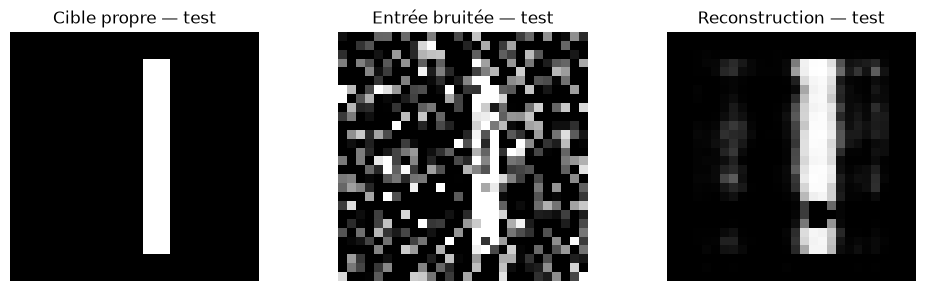

In [6]:
sample_index = 0
sample_denoised = reconstructed_test[sample_index].reshape(28, 28).numpy()

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(clean_images[split + sample_index], cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Cible propre — test")
axes[1].imshow(noisy_images[split + sample_index], cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Entrée bruitée — test")
axes[2].imshow(sample_denoised, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("Reconstruction — test")
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()

assert np.isfinite(mse_autoencoder)
assert mse_autoencoder < mse_noisy_input, (
    "Le débruitage n'améliore pas la baseline : revoir l'entraînement."
)


## 4. Panorama des familles génératives

- **VAE** : apprend une distribution latente régularisée et permet d'échantillonner de nouvelles représentations.
- **GAN** : oppose générateur et discriminateur ; il peut produire des échantillons nets mais l'optimisation est délicate.
- **Diffusion** : apprend un processus de débruitage et génère à partir d'un échantillon de bruit, éventuellement conditionné.

Ces familles ne forment pas une chronologie où la plus récente remplace toujours les autres : le choix dépend des données, du coût et de l'usage.

---

## 5. Exercice guidé : masque causal

Empêchez chaque position de regarder les positions futures en ajoutant `-inf` au triangle supérieur des scores avant le softmax.

**Critère de réussite** : tous les poids strictement au-dessus de la diagonale sont nuls.


In [7]:
# À vous de jouer.
# TODO : construire causal_mask puis calculer causal_attention_weights.


In [8]:
causal_mask = torch.triu(
    torch.full_like(scaled_scores, float('-inf')),
    diagonal=1,
)
causal_attention_weights = F.softmax(scaled_scores + causal_mask, dim=-1)

future_weights = torch.triu(causal_attention_weights, diagonal=1)
assert torch.allclose(future_weights, torch.zeros_like(future_weights))
assert torch.allclose(
    causal_attention_weights.sum(dim=1),
    torch.ones(seq_len),
)
print(causal_attention_weights.detach().numpy().round(3))


[[1.    0.    0.    0.   ]
 [0.432 0.568 0.    0.   ]
 [0.41  0.294 0.297 0.   ]
 [0.172 0.268 0.367 0.193]]


## Conclusion et auto-évaluation

1. Les poids d'attention sont des sorties d'un calcul ; sans entraînement, ils n'ont pas de signification linguistique acquise.
2. Le masque causal empêche l'accès aux positions futures.
3. L'auto-encodeur est évalué sur des images non vues, avec une baseline fournie par l'entrée bruitée.
4. Ce TP présente des briques ; construire un Transformer ou un modèle génératif complet demande des objectifs et protocoles supplémentaires.
